#**CHAPTER 2.BAYESIAN NEURAL NETWORKS**
---

##REFERENCE

https://chatgpt.com/share/69acbf2d-db54-8012-891c-6d9bb26e90d9

##0.CONTEXT

**Introduction**

Bayesian neural networks occupy a fascinating place in modern machine learning because they sit at the intersection of two powerful ideas. The first idea is the neural network, which gives us flexible function approximators capable of learning highly nonlinear relationships from data. The second idea is Bayesian inference, which gives us a mathematical language for expressing uncertainty, updating beliefs, and avoiding the illusion that a trained model knows more than the evidence truly supports. When these two ideas are brought together, the result is not simply “a neural network with probabilities.” It is a different way of thinking about learning itself. Instead of treating the weights of the neural network as fixed but unknown numbers that must be estimated once and for all, a Bayesian neural network treats them as uncertain quantities described by probability distributions. That shift changes the meaning of training, prediction, confidence, and even error.

To understand why this matters, it is useful to begin with the more familiar deterministic neural network. In an ordinary feedforward neural network, the model is defined by layers of weights and biases. During training, the system adjusts those weights to minimize a loss function on the training data. Once training ends, the weights are fixed. If a new input arrives, the network passes it through the learned transformation and produces a prediction. This can work extremely well. In many pattern-recognition tasks, deterministic neural networks achieve very high accuracy. But there is a conceptual weakness hidden inside this success. The network often behaves as though the final learned weights were known with certainty. It does not naturally distinguish between a case in which the data strongly justify a particular prediction and a case in which the prediction is based on weaker or more ambiguous evidence. It can still output probabilities through a softmax layer, but those probabilities are not the same thing as a deep representation of uncertainty. They are often just normalized scores from a fixed parameter setting.

This is where Bayesian neural networks become important. A Bayesian neural network does not commit to one final set of weights. Instead, it represents each weight with a probability distribution. During training, the goal is not simply to find the best point estimate, but to learn a posterior distribution over plausible values of the weights given the data. In practical implementations, one often uses approximate Bayesian inference because the exact posterior is usually intractable for neural networks of nontrivial size. Even so, the central idea remains powerful. The model learns not only where in weight space the data point, but also how certain or uncertain that conclusion should be. Prediction then becomes an averaging process over possible weight realizations rather than a single deterministic pass.

This has major implications for pattern recognition. Pattern-recognition problems are often taught as if every input belongs neatly to one class and the only challenge is building a sufficiently clever classifier to recover the correct boundary. Real systems are rarely so tidy. Inputs may be corrupted by noise, shifted slightly relative to training examples, partially occluded, or structured in ways that lie between categories. Some examples are easy, while others are genuinely ambiguous. A deterministic neural network may still force a sharp answer. A Bayesian neural network can instead express hesitation. It can say, in effect, that this input most likely belongs to one class, but that alternative interpretations remain plausible. In scientific or high-stakes settings, this is enormously valuable.

The notebook we generated provides a particularly clean environment in which to study these ideas because it uses synthetic 10x10 visual patterns. At first glance, a 10x10 grid may seem almost toy-like compared with large image datasets. But in fact it is a very powerful pedagogical choice. The patterns are small enough to visualize directly and understand intuitively, yet rich enough to support nontrivial classification. Horizontal bars, vertical bars, diagonal structures, crosses, frame borders, and checker-like patches are distinct visual motifs. At the same time, once noise, local corruption, thickness variation, and positional shifts are introduced, the task becomes meaningfully uncertain. A diagonal may become broken. A cross may resemble the overlap of a horizontal and a vertical line. A checker patch may be distorted enough to look partially like a frame or a noisy cluster. This is exactly the kind of setting in which Bayesian uncertainty becomes intellectually visible.

Synthetic data are especially useful here because they let us control the problem. In a real dataset, we often do not know whether uncertainty is coming from bad labels, poor data collection, irrelevant background structure, or genuine class overlap. In a synthetic dataset, we know the generating logic. We know which patterns exist, how they are perturbed, and how balanced the classes are. This means that when the Bayesian neural network becomes uncertain, we can reason carefully about why. Is the example close to a class boundary? Is the corruption especially severe? Is one pattern family inherently more variable than another? The synthetic setting makes these questions answerable in a way that is often difficult with large real-world benchmarks.

The Bayesian part of the notebook is implemented through variational inference. This is important because fully exact Bayesian inference for neural networks is typically impossible in practice for models of useful size. Variational inference offers a principled approximation. Instead of solving for the true posterior over weights directly, we define a simpler family of distributions over the weights, often Gaussian distributions with learnable means and scales, and then optimize those variational parameters so that the approximating distribution becomes as close as possible to the true posterior. In the notebook, each Bayesian linear layer contains a mean parameter and a scale-related parameter for every weight and bias. During the forward pass, the model samples weights using the reparameterization trick. This means that prediction is inherently stochastic during both training and inference.

The reparameterization trick deserves special emphasis because it is one of the elegant engineering ideas that makes Bayesian neural networks practical. If weights are sampled directly in an uncontrolled way, gradient-based optimization becomes difficult because the randomness interrupts differentiation. The reparameterization trick solves this by writing a sampled weight as a deterministic transformation of a learnable mean and scale plus a random noise variable drawn from a fixed distribution. In simple form, a sampled weight becomes mean plus standard deviation times standard normal noise. This preserves stochasticity while keeping the computation differentiable with respect to the learnable parameters. In other words, it allows the network to be trained by familiar gradient methods while still behaving as a probabilistic model.

Training a Bayesian neural network also changes the loss function. In a deterministic classifier, we often optimize only the predictive loss, such as cross-entropy. In a Bayesian neural network, we usually optimize a form of evidence lower bound, often described as the sum of a negative log-likelihood term and a Kullback-Leibler divergence term. The predictive term rewards the model for fitting the data. The KL term measures how far the learned weight distributions depart from a chosen prior distribution. This creates a natural tension. The model wants to explain the data well, but it is also penalized for drifting too far from the prior without sufficient evidence. This acts like a probabilistic regularizer. It encourages the network not to become more certain than the data justify.

That point is central to the intellectual value of Bayesian neural networks. Ordinary regularization methods such as weight decay or dropout can also control overfitting, but they do not usually provide a direct probabilistic interpretation of uncertainty. The KL term in a variational Bayesian neural network does more than shrink the parameters. It expresses the idea that complex, highly specific parameter settings must be earned by the evidence. If the data strongly support a particular weight pattern, the posterior can move away from the prior. If the evidence is weaker, the posterior remains broader and closer to the prior. This is a very attractive scientific logic.

At test time, Bayesian neural networks also behave differently. In a deterministic network, one forward pass gives the final answer. In a Bayesian neural network, one typically performs multiple stochastic forward passes, each one sampling a different plausible set of weights from the learned posterior approximation. The resulting predictions are then averaged. This Monte Carlo procedure gives us a predictive mean, which acts as the final class-probability estimate. More importantly, it lets us measure predictive uncertainty. If the sampled networks largely agree, the model is confident. If they disagree, the predictive distribution becomes more diffuse. This is a key reason why Bayesian neural networks are often described as uncertainty-aware models.

In our notebook, predictive entropy is used as a simple and meaningful uncertainty summary. Entropy is low when one class probability dominates and high when the probabilities are spread across several classes. This is pedagogically very useful because students can look at a noisy 10x10 pattern and compare what their own visual intuition says with what the entropy says. A clearly recognizable horizontal bar should usually produce low entropy. A corrupted diagonal that now resembles part of a cross may produce higher entropy. This gives a concrete bridge between human intuition and probabilistic machine learning.

The notebook also emphasizes visualization, and this is exactly the right choice for this topic. Bayesian neural networks are sometimes taught too abstractly, through equations alone, which can make the concepts feel remote. But uncertainty becomes much more intuitive when shown through grids of images, learning curves, confusion matrices, entropy histograms, and bar charts of predictive probabilities. Visualization lets us see what the model learned, where it struggles, and how its uncertainty changes across examples. In a pattern-recognition notebook, this is not decoration. It is part of the scientific argument.

There is also a broader reason why this notebook matters. Although the data are synthetic visual patterns, the logic generalizes to many other domains. In finance, one may want to classify market regimes, detect anomalies, interpret cross-asset structures, or identify stressed versus calm states. In medicine, one may want to classify images or signals while avoiding false certainty. In industrial systems, one may want to recognize fault patterns without overreacting to ambiguous sensor readings. In all of these cases, uncertainty matters. A model that is accurate but falsely overconfident can be more dangerous than a model that is slightly less accurate but knows when it does not know.

This is why Bayesian neural networks are such an important topic for advanced machine learning education. They force us to confront a deeper question than mere accuracy: what should a model believe, and how certain should it be? They move us away from the simplistic idea that learning is just parameter optimization and toward the richer idea that learning is belief updating under uncertainty. They also provide a practical bridge between classical Bayesian statistics and modern deep learning, showing that probabilistic reasoning is not limited to small linear models but can be brought into flexible neural architectures.

At the same time, Bayesian neural networks are not magic. Their posterior is usually approximate, not exact. Variational approximations may underestimate uncertainty in some settings. The model’s behavior still depends on architecture choice, data quality, prior choice, and optimization stability. But even with these caveats, they offer a major conceptual advance over purely deterministic neural classifiers. They do not just tell us what class seems most likely. They give us a language for expressing how strongly the evidence supports that conclusion.

The notebook we generated is therefore a compact but serious research laboratory. It is compact because the grids are small, the classes are synthetic, and the architecture is lightweight enough to run comfortably in Colab. But it is serious because every major ingredient of Bayesian neural network practice is present: stochastic weights, variational parameters, KL regularization, Monte Carlo prediction, predictive uncertainty, visualization of ambiguous examples, and structured performance evaluation. This makes it an ideal teaching and experimentation platform.

If one learns this notebook deeply, one is not merely learning how to classify 10x10 patterns. One is learning how uncertainty can be embedded into neural computation. One is learning how to distinguish easy cases from hard ones, how to interpret probability as something richer than a softmax score, and how to inspect a model scientifically rather than just celebrate its accuracy. In that sense, the notebook is a small but powerful demonstration of a large idea: intelligent systems should not only make predictions, they should also know how uncertain they are when making them.

That is the real significance of Bayesian neural networks. They do not just expand the toolbox of machine learning. They reshape the meaning of what it means for a model to have learned.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 Explanation**

Cell 1 establishes the computational environment and the experimental discipline for the entire notebook. At a superficial level, it simply imports libraries, sets a seed, defines an output directory, and configures plotting defaults. But pedagogically, this cell is much more important than it may first appear. In a serious machine learning notebook, the setup cell defines the conditions under which every later result will be interpreted. If this cell is sloppy, then the rest of the notebook is built on unstable ground.

The first key idea in this cell is reproducibility. By setting the random seed for Python’s random module, NumPy, and PyTorch, the notebook ensures that the synthetic data generation, parameter initialization, and stochastic training steps can be reproduced. This matters a great deal in a Bayesian neural network notebook because randomness appears at several levels. The synthetic patterns are noisy. The Bayesian layers sample weights. The training minibatches are shuffled. Without seed control, each run could produce meaningfully different outputs. That would make learning from the notebook harder because the target would keep shifting. The seed therefore acts like a scientific anchor.

The second important aspect is the selection of libraries. Only basic and truly necessary libraries are used: NumPy for array operations, Matplotlib for visualization, and PyTorch for neural-network and tensor computation. This is pedagogically wise. A notebook about Bayesian neural networks should emphasize the model logic, not hide everything inside a huge software stack. By limiting dependencies, the notebook remains transparent and easier to debug. Students can more easily see what each line is doing.

The device configuration is another useful ingredient. The notebook checks whether a GPU is available and otherwise falls back to CPU. This is standard practice in PyTorch notebooks and makes the code portable across Colab and local environments. Even though this problem is small enough to run on CPU, it is still good practice to write device-aware code from the beginning.

The artifact directory created in this cell is also scientifically important. Instead of letting results exist only on screen, the notebook prepares a place to save metadata, training history, and final results. This turns the notebook into a mini research lab rather than a disposable classroom script.

Finally, the plotting configuration helps create consistent visuals throughout the notebook. Since visualization is central to understanding uncertainty in this project, setting a stable plotting style early contributes to readability and continuity.

So Cell 1 does not merely “set things up.” It establishes reproducibility, transparency, computational portability, artifact discipline, and visual consistency. In other words, it defines the experimental culture of the notebook.

In [4]:
# Cell 1
# Environment setup, imports, seeds, plotting defaults, output directory

import math
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ARTIFACT_DIR = Path("bnn_pattern_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

print("Bayesian Neural Networks for Synthetic 10x10 Pattern Recognition")
print("Seed:", SEED)
print("Device:", DEVICE)
print("Artifacts:", ARTIFACT_DIR.resolve())

Bayesian Neural Networks for Synthetic 10x10 Pattern Recognition
Seed: 123
Device: cpu
Artifacts: /content/bnn_pattern_artifacts


##2.SYNTHETIC PATTERN GENERATOR

###2.1.OVERVIEW

**Cell 2 Explanation**

Cell 2 is the generative foundation of the notebook because it defines the pattern-recognition world the Bayesian neural network will try to understand. Without this cell, there is no task, no classes, and no meaningful uncertainty to study. It is therefore one of the most conceptually important parts of the notebook.

The first thing this cell does is define the grid size and class structure. Every image is a 10x10 binary grid, and the classes correspond to specific visual motifs: horizontal bars, vertical bars, main diagonals, crosses, frame borders, and checker-like patches. This is a very smart design choice pedagogically. The patterns are simple enough for a human to recognize instantly, which makes it easier to compare the model’s behavior with visual intuition. At the same time, the set of classes is diverse enough to create genuine classification challenges once noise is added.

Each pattern-generating function represents a class prototype. For example, the horizontal-bar function activates one or two rows, while the vertical-bar function activates columns. The diagonal function introduces directionality. The cross combines a horizontal and a vertical structure. The frame border emphasizes the edges of the image, and the checker patch creates a textured local motif rather than a simple line. These different geometries matter because they define what kinds of features the Bayesian neural network must distinguish.

The cell becomes truly interesting when controlled variation is introduced. The patterns are not generated in one perfectly rigid form. Thickness can vary. Position can shift. Noise can flip bits. Extra random activations can appear. This is pedagogically excellent because it prevents the problem from collapsing into trivial memorization. If every class had only one exact clean prototype, the network would learn the task too easily and uncertainty would be almost uninteresting. By adding stochastic corruption, the notebook creates examples that can lie near class boundaries.

The helper functions also illustrate good software design. There are small modular functions for blank grids, clipping indices, adding noise, and thickening lines. This makes the code readable and extendable. If one later wanted to add more pattern families, stronger corruption, or different geometric primitives, the notebook could be adapted easily.

Most importantly, Cell 2 defines the scientific meaning of uncertainty in the notebook. Once a horizontal bar is shifted, thickened, and partially corrupted, it may begin to resemble another class. A cross with missing segments might look partly like a vertical bar. A distorted checker patch may become harder to distinguish from a noisy frame. These are the exact situations in which a Bayesian neural network should become less certain. Thus Cell 2 is where the conditions for meaningful Bayesian behavior are created.

In summary, Cell 2 does much more than generate toy images. It defines the latent structure of the classification problem, introduces controlled ambiguity, and creates the visual universe in which Bayesian uncertainty can later be observed and interpreted.

###2.2.CODE AND IMPLEMENTATION

In [5]:
# Cell 2
# Synthetic pattern generator functions and class definitions

GRID_SIZE = 10
N_CLASSES = 6
CLASS_NAMES = {
    0: "horizontal_bar",
    1: "vertical_bar",
    2: "main_diagonal",
    3: "cross",
    4: "frame_border",
    5: "checker_patch"
}

def blank_grid(size=GRID_SIZE):
    return np.zeros((size, size), dtype=np.float32)

def clip_index(v, low=0, high=GRID_SIZE - 1):
    return int(max(low, min(high, v)))

def add_noise(grid, flip_prob=0.04):
    mask = np.random.rand(*grid.shape) < flip_prob
    out = grid.copy()
    out[mask] = 1.0 - out[mask]
    return out

def thicken_line(grid, axis, idx, thickness):
    for offset in range(-(thickness // 2), thickness - thickness // 2):
        j = clip_index(idx + offset)
        if axis == "h":
            grid[j, :] = 1.0
        elif axis == "v":
            grid[:, j] = 1.0
    return grid

def pattern_horizontal_bar():
    g = blank_grid()
    row = np.random.randint(2, 8)
    thickness = np.random.choice([1, 2])
    g = thicken_line(g, "h", row, thickness)
    return g

def pattern_vertical_bar():
    g = blank_grid()
    col = np.random.randint(2, 8)
    thickness = np.random.choice([1, 2])
    g = thicken_line(g, "v", col, thickness)
    return g

def pattern_main_diagonal():
    g = blank_grid()
    shift = np.random.choice([-1, 0, 1])
    thickness = np.random.choice([1, 2])
    for i in range(GRID_SIZE):
        j = i + shift
        if 0 <= j < GRID_SIZE:
            for t in range(thickness):
                jj = j + t
                if 0 <= jj < GRID_SIZE:
                    g[i, jj] = 1.0
    return g

def pattern_cross():
    g = blank_grid()
    row = np.random.randint(3, 7)
    col = np.random.randint(3, 7)
    thickness = np.random.choice([1, 2])
    g = thicken_line(g, "h", row, thickness)
    g = thicken_line(g, "v", col, thickness)
    return g

def pattern_frame_border():
    g = blank_grid()
    margin = np.random.choice([0, 1])
    g[margin, margin:GRID_SIZE-margin] = 1.0
    g[GRID_SIZE - 1 - margin, margin:GRID_SIZE-margin] = 1.0
    g[margin:GRID_SIZE-margin, margin] = 1.0
    g[margin:GRID_SIZE-margin, GRID_SIZE - 1 - margin] = 1.0
    return g

def pattern_checker_patch():
    g = blank_grid()
    top = np.random.randint(1, 4)
    left = np.random.randint(1, 4)
    h = np.random.choice([4, 5, 6])
    w = np.random.choice([4, 5, 6])
    bottom = min(GRID_SIZE, top + h)
    right = min(GRID_SIZE, left + w)
    for i in range(top, bottom):
        for j in range(left, right):
            if (i + j) % 2 == 0:
                g[i, j] = 1.0
    return g

PATTERN_FUNCS = {
    0: pattern_horizontal_bar,
    1: pattern_vertical_bar,
    2: pattern_main_diagonal,
    3: pattern_cross,
    4: pattern_frame_border,
    5: pattern_checker_patch
}

def make_sample(class_id, noise_prob=0.05):
    grid = PATTERN_FUNCS[class_id]()
    if np.random.rand() < 0.7:
        grid = add_noise(grid, flip_prob=noise_prob)
    if np.random.rand() < 0.2:
        i = np.random.randint(0, GRID_SIZE)
        j = np.random.randint(0, GRID_SIZE)
        grid[i, j] = 1.0
    return grid.astype(np.float32)

print("Classes:", CLASS_NAMES)

Classes: {0: 'horizontal_bar', 1: 'vertical_bar', 2: 'main_diagonal', 3: 'cross', 4: 'frame_border', 5: 'checker_patch'}


##3.DATASET

###3.1.OVERVIEW

**Cell 3 Explanation**

Cell 3 takes the generative logic from Cell 2 and turns it into actual datasets for training, validation, and testing. Pedagogically, this cell is where the notebook stops being an abstract description of patterns and becomes a usable machine learning experiment.

The first major idea is balanced dataset construction. For each class, the code generates the same number of examples. This is important because class imbalance can complicate interpretation. If one class were heavily overrepresented, then accuracy and confidence could be distorted simply because the model sees that class more often. By keeping the classes balanced, the notebook makes it easier to attribute model behavior to pattern structure rather than sampling asymmetry.

The second important idea is dataset splitting. The notebook creates separate training, validation, and test sets, each with slightly different noise levels. This is a very instructive choice. The training data are noisy but not excessively so. The validation data are comparable. The test data are slightly more corrupted. This means the test set is not just a copy of training conditions. It is a mildly harder benchmark. That helps make the final evaluation more meaningful because the Bayesian neural network must generalize under somewhat harsher conditions.

The shuffle applied after data generation is also a key detail. Without shuffling, the dataset would be ordered class by class, which could create unwanted structure in minibatching and visualization. Random shuffling ensures that the model sees a mixed stream of classes during training.

The summary function in this cell serves an important diagnostic role. It prints the shape of each split, the average density of activated pixels, and the class counts. This allows the notebook author and the student to verify that the data look sensible before moving on. For example, if the density were too low or too high, the patterns might be too sparse or too saturated. If class counts were off, then the experiment design would need correction. These checks are small but scientifically valuable.

Saving metadata to JSON is another sign of good practice. It records the seed, the grid size, the class names, and dataset shapes. This is helpful for reproducibility and also for documentation. A notebook that saves structured metadata is easier to revisit later and easier to compare with modified variants.

Conceptually, Cell 3 also introduces the idea that the dataset itself is an experimental object. In many beginner notebooks, data are treated as a passive input. Here, because the data are synthetic, the dataset is part of the model design. The train/validation/test splits, their sizes, and their corruption levels all shape what the Bayesian neural network can learn and how uncertainty will behave.

So Cell 3 is not merely a data-loading step. It creates the full empirical foundation of the notebook, validates that the synthetic world has the intended scale and balance, and stores essential experimental metadata for later use.

###3.2.CODE AND IMPLEMENTATION

In [6]:
# Cell 3
# Dataset generation for train/validation/test and printed summaries

def build_dataset(n_per_class, noise_prob=0.05):
    xs, ys = [], []
    for class_id in range(N_CLASSES):
        for _ in range(n_per_class):
            xs.append(make_sample(class_id, noise_prob=noise_prob))
            ys.append(class_id)
    X = np.stack(xs).astype(np.float32)
    y = np.array(ys, dtype=np.int64)

    idx = np.arange(len(y))
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]
    return X, y

X_train, y_train = build_dataset(n_per_class=700, noise_prob=0.05)
X_val, y_val = build_dataset(n_per_class=150, noise_prob=0.06)
X_test, y_test = build_dataset(n_per_class=150, noise_prob=0.08)

def summarize_split(name, X, y):
    counts = {CLASS_NAMES[k]: int((y == k).sum()) for k in range(N_CLASSES)}
    density = float(X.mean())
    print(f"{name}: shape={X.shape}, density={density:.4f}, class_counts={counts}")

summarize_split("train", X_train, y_train)
summarize_split("val", X_val, y_val)
summarize_split("test", X_test, y_test)

metadata = {
    "seed": SEED,
    "grid_size": GRID_SIZE,
    "n_classes": N_CLASSES,
    "class_names": CLASS_NAMES,
    "train_shape": list(X_train.shape),
    "val_shape": list(X_val.shape),
    "test_shape": list(X_test.shape),
}
with open(ARTIFACT_DIR / "dataset_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved dataset metadata.")

train: shape=(4200, 10, 10), density=0.2155, class_counts={'horizontal_bar': 700, 'vertical_bar': 700, 'main_diagonal': 700, 'cross': 700, 'frame_border': 700, 'checker_patch': 700}
val: shape=(900, 10, 10), density=0.2219, class_counts={'horizontal_bar': 150, 'vertical_bar': 150, 'main_diagonal': 150, 'cross': 150, 'frame_border': 150, 'checker_patch': 150}
test: shape=(900, 10, 10), density=0.2302, class_counts={'horizontal_bar': 150, 'vertical_bar': 150, 'main_diagonal': 150, 'cross': 150, 'frame_border': 150, 'checker_patch': 150}
Saved dataset metadata.


##4.VISUALIZATION

###4.1.OVERVIEW

**Cell 4 Explanation**

Cell 4 is the first major visualization cell, and it plays an essential pedagogical role. Before training a Bayesian neural network, it is important to actually see the data. Machine learning can become too abstract too quickly if students move from code directly into optimization without first building visual intuition about the patterns being learned.

The first figure in this cell shows representative training examples from every class. Each row corresponds to one class, and multiple examples are shown side by side. This is extremely useful because it reveals both the structure and the variability of each pattern family. One can see that horizontal bars are not always in the same row, vertical bars shift position, diagonals can be slightly displaced, crosses vary in center, frame borders may have small differences, and checker patches are local and noisy. By looking across the examples, the student understands that each class is a distribution of patterns, not one rigid template.

This is exactly the right intuition for Bayesian neural networks. A Bayesian model is built for settings in which data within a class vary and different classes can overlap. The visual montage in this cell makes that idea concrete. One can already anticipate where uncertainty may emerge. For example, a noisy cross may look similar to a combination of horizontal and vertical bar features. A corrupted border may contain fragments that resemble local patches. Seeing these examples helps the student later understand why some predictions are confident and others ambiguous.

The second figure compares clean and noisy examples class by class. This is pedagogically powerful because it separates prototype structure from corruption effects. The top row shows the idealized clean pattern, while the bottom row shows a noisy variant. This makes the classification challenge much easier to reason about. The student can ask: what information survives corruption, and what information becomes ambiguous? In other words, this figure introduces the notion of robustness.

Cell 4 therefore does not merely provide pretty pictures. It creates the interpretive bridge between synthetic data generation and model learning. It gives a human baseline. If the human eye can still easily recognize most noisy examples, then the network should likely achieve strong performance. If some noisy examples already look questionable to a human, then uncertainty in the Bayesian neural network should be expected and welcomed.

Another subtle value of this cell is that it validates the synthetic generator. If the classes were not visually distinct enough, or if the corruption were too severe, the problem might be poorly posed. Conversely, if the corruption were too weak, the task would be too easy and uncertainty would not be very informative. Cell 4 lets us inspect that balance.

In summary, Cell 4 is the notebook’s visual sanity check and intuitive orientation device. It helps the learner understand the dataset as a family of structured but variable patterns and sets the stage for later interpretation of classification success, ambiguity, and uncertainty.

###4.2.CODE AND IMPLEMENTATION

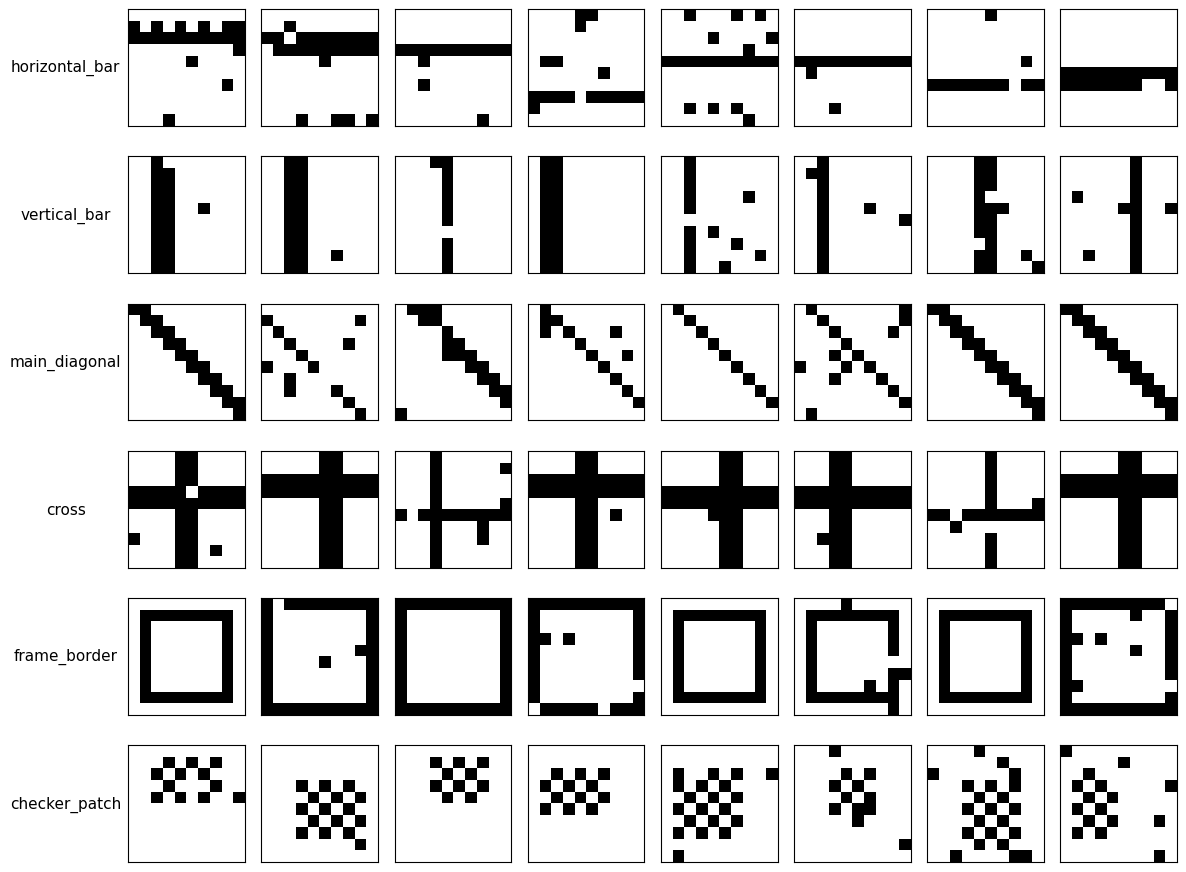

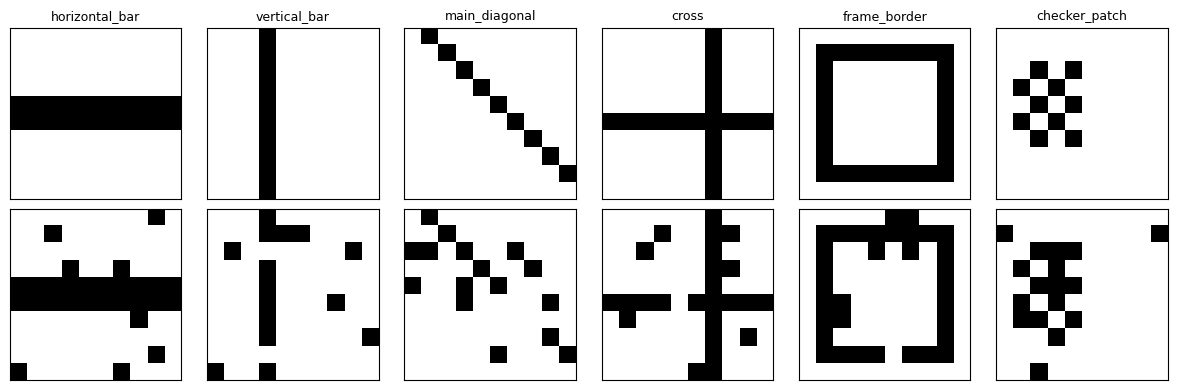

In [7]:
# Cell 4
# Visualization of representative samples from all classes

fig, axes = plt.subplots(N_CLASSES, 8, figsize=(12, 9))
for class_id in range(N_CLASSES):
    idxs = np.where(y_train == class_id)[0][:8]
    for j, idx in enumerate(idxs):
        axes[class_id, j].imshow(X_train[idx], cmap="gray_r", vmin=0, vmax=1)
        axes[class_id, j].set_xticks([])
        axes[class_id, j].set_yticks([])
        if j == 0:
            axes[class_id, j].set_ylabel(CLASS_NAMES[class_id], rotation=0, labelpad=45, va="center")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for class_id in range(N_CLASSES):
    clean = PATTERN_FUNCS[class_id]()
    noisy = add_noise(clean, flip_prob=0.10)
    axes[0, class_id].imshow(clean, cmap="gray_r", vmin=0, vmax=1)
    axes[0, class_id].set_title(CLASS_NAMES[class_id], fontsize=9)
    axes[0, class_id].set_xticks([])
    axes[0, class_id].set_yticks([])
    axes[1, class_id].imshow(noisy, cmap="gray_r", vmin=0, vmax=1)
    axes[1, class_id].set_xticks([])
    axes[1, class_id].set_yticks([])
plt.tight_layout()
plt.show()

##5.TENSOR PREPARATION AND AND DATALOADERS

###5.1.OVERVIEW

**Cell 5 Explanation**

Cell 5 performs the transition from NumPy-based synthetic image arrays to PyTorch-ready datasets and dataloaders. Pedagogically, this cell is important because it shows how raw visual patterns become machine-learning inputs that a neural network can process efficiently.

The first key step is flattening each 10x10 grid into a 100-dimensional vector. This is appropriate because the model used in the notebook is a Bayesian multilayer perceptron, not a convolutional network. A multilayer perceptron expects a vector input, so each image must be reshaped from matrix form into a single feature vector. This is a good teaching choice because it keeps the architecture simple and lets students focus on Bayesian uncertainty rather than convolutional mechanics. At the same time, it is useful to understand what is lost here: flattening removes explicit spatial locality. The network can still learn patterns, but it must infer spatial relationships from vector positions rather than from convolutional filters.

The conversion into PyTorch tensors is the second major step. PyTorch requires tensors, not NumPy arrays, for gradient-based training. The features are cast to floating-point tensors, and the labels become long integer tensors suitable for classification loss functions such as cross-entropy. This reinforces a practical lesson in deep learning: numerical type discipline matters.

The use of TensorDataset is pedagogically neat because it packages features and labels together in a minimal but robust way. This keeps the notebook lightweight while still following standard PyTorch workflows.

The dataloaders are another crucial ingredient. They handle batching and shuffling automatically. Training uses shuffled minibatches, which improves stochastic gradient optimization and prevents the model from seeing data in a fixed order. Validation and test loaders are not shuffled, since ordering is irrelevant there and stable iteration is often more convenient.

The batch size also deserves attention. A moderate batch size like 128 balances efficiency and stochasticity. For Bayesian neural networks, this matters because training already contains internal randomness through sampled weights. The minibatch structure adds another layer of variability, which can help optimization but also needs to remain stable enough for learning.

The printed sample shapes at the end of the cell are simple but useful diagnostics. They confirm that the batch structure is correct and that the flattened input dimension is 100. This is pedagogically important because many training errors in neural-network notebooks come from mismatched dimensions. By printing these shapes early, the notebook reduces the chance of confusion later.

Conceptually, Cell 5 is where the synthetic visual problem becomes a formal supervised learning problem in tensor form. It translates images into vectors, labels into training targets, and arrays into iterable minibatches. While this may seem like a routine engineering step, it is actually central to understanding how abstract pattern classes are converted into something a Bayesian neural network can optimize over.

So Cell 5 should be understood as the data-interface cell. It connects the visual world of the synthetic patterns to the probabilistic computational world of PyTorch-based Bayesian learning.

###5.2.CODE AND IMPLEMENTATION

In [8]:
# Cell 5
# Tensor preparation and dataloaders

def to_tensor_dataset(X, y):
    Xf = X.reshape(len(X), -1)
    Xf = torch.tensor(Xf, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)
    return TensorDataset(Xf, y)

train_ds = to_tensor_dataset(X_train, y_train)
val_ds = to_tensor_dataset(X_val, y_val)
test_ds = to_tensor_dataset(X_test, y_test)

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

sample_x, sample_y = next(iter(train_loader))
print("Batch X shape:", sample_x.shape)
print("Batch y shape:", sample_y.shape)
print("Input dimension:", sample_x.shape[1])

Batch X shape: torch.Size([128, 100])
Batch y shape: torch.Size([128])
Input dimension: 100


##6.BAYESIAN NEURAL NETWORK IMPLEMENTATION

###6.1.OVERVIEW

**Cell 6 Explanation**

Cell 6 is the mathematical heart of the notebook because it defines the Bayesian neural network itself. This is the cell where the project truly becomes a Bayesian neural network experiment rather than an ordinary pattern-classification notebook.

The core building block is the BayesianLinear layer. In a deterministic linear layer, each weight and bias is a fixed learnable number. Here, each weight and bias instead has two learnable parameters: a mean and a rho parameter that is transformed into a positive scale. This is the essence of the variational approximation. Rather than trying to learn one final value for each parameter, the model learns a distribution over plausible values. That is what makes the layer Bayesian in practice.

The softplus-like transformation from rho to sigma is important. Standard deviations must be positive, so the model cannot learn them directly without constraints. By learning rho and mapping it through a monotonic transformation, the notebook ensures positivity while keeping optimization stable.

The sample_params method implements the reparameterization trick. Instead of sampling the weight directly in an opaque way, the code samples a standard normal noise tensor and scales and shifts it using the learned mean and sigma. This keeps the random sampling compatible with backpropagation. Pedagogically, this is one of the most important ideas in modern Bayesian deep learning. It shows how randomness and gradient optimization can coexist.

The KL-divergence function is another central concept. It measures how far the learned posterior approximation is from the Gaussian prior. This acts as a regularizer, but more than that, it is the Bayesian penalty that prevents the posterior from drifting too far from prior belief without sufficient support from the data. In other words, the model is being asked to explain the training data well while also staying probabilistically disciplined.

The BayesianMLP then stacks three BayesianLinear layers with ReLU activations in between. This creates a nonlinear classifier while preserving stochastic weight sampling throughout the network. Every forward pass uses sampled parameters, so the network’s output is inherently random conditional on the learned variational distributions.

Printing the model and the total parameter count is useful because it gives the student a concrete sense of the architecture’s scale. Although the images are tiny, the Bayesian network still contains many learnable quantities because every weight now has both a mean and a scale parameter.

Conceptually, Cell 6 teaches a profound lesson: a Bayesian neural network is not just a neural network with a probability output. It is a network whose internal parameters are uncertain and whose forward computations are stochastic. This changes the meaning of learning. The model is not only fitting a function. It is learning a distribution over functions, approximated through distributions over weights.

That is why Cell 6 is so central. It translates Bayesian principles into executable deep-learning machinery and creates the probabilistic engine that drives everything that follows in the notebook.

###6.2.CODE AND IMPLEMENTATION

In [9]:
# Cell 6
# Bayesian neural network implementation with Bayesian linear layers and KL divergence

class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_sigma = prior_sigma

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features).normal_(0, 0.1))
        self.weight_rho = nn.Parameter(torch.empty(out_features, in_features).fill_(-3.0))
        self.bias_mu = nn.Parameter(torch.empty(out_features).normal_(0, 0.1))
        self.bias_rho = nn.Parameter(torch.empty(out_features).fill_(-3.0))

    def _sigma(self, rho):
        return torch.log1p(torch.exp(rho))

    def sample_params(self):
        weight_sigma = self._sigma(self.weight_rho)
        bias_sigma = self._sigma(self.bias_rho)

        eps_w = torch.randn_like(self.weight_mu)
        eps_b = torch.randn_like(self.bias_mu)

        weight = self.weight_mu + weight_sigma * eps_w
        bias = self.bias_mu + bias_sigma * eps_b
        return weight, bias, weight_sigma, bias_sigma

    def kl_divergence(self):
        weight_sigma = self._sigma(self.weight_rho)
        bias_sigma = self._sigma(self.bias_rho)

        prior_var = self.prior_sigma ** 2

        kl_w = torch.sum(
            torch.log(torch.tensor(self.prior_sigma, device=self.weight_mu.device) / weight_sigma)
            + (weight_sigma ** 2 + self.weight_mu ** 2) / (2 * prior_var)
            - 0.5
        )
        kl_b = torch.sum(
            torch.log(torch.tensor(self.prior_sigma, device=self.bias_mu.device) / bias_sigma)
            + (bias_sigma ** 2 + self.bias_mu ** 2) / (2 * prior_var)
            - 0.5
        )
        return kl_w + kl_b

    def forward(self, x):
        weight, bias, _, _ = self.sample_params()
        return F.linear(x, weight, bias)

class BayesianMLP(nn.Module):
    def __init__(self, input_dim=100, hidden_dim=128, n_classes=N_CLASSES, prior_sigma=1.0):
        super().__init__()
        self.b1 = BayesianLinear(input_dim, hidden_dim, prior_sigma=prior_sigma)
        self.b2 = BayesianLinear(hidden_dim, hidden_dim, prior_sigma=prior_sigma)
        self.b3 = BayesianLinear(hidden_dim, n_classes, prior_sigma=prior_sigma)

    def forward(self, x):
        x = F.relu(self.b1(x))
        x = F.relu(self.b2(x))
        x = self.b3(x)
        return x

    def kl_divergence(self):
        return self.b1.kl_divergence() + self.b2.kl_divergence() + self.b3.kl_divergence()

model = BayesianMLP(input_dim=GRID_SIZE * GRID_SIZE, hidden_dim=128, n_classes=N_CLASSES, prior_sigma=1.0).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print("Number of parameters:", n_params)

BayesianMLP(
  (b1): BayesianLinear()
  (b2): BayesianLinear()
  (b3): BayesianLinear()
)
Number of parameters: 60428


##7.TRAINING LOOP

###7.1.OVERVIEW

**Cell 7 Explanation**

Cell 7 performs the training of the Bayesian neural network. Pedagogically, this is where the notebook’s theoretical ideas are turned into an optimization process. It is one thing to define stochastic layers and KL divergence; it is another to see how these pieces work together during learning.

The training loop is built around an evidence-lower-bound style objective. In practical terms, the loss is composed of two parts. The first is the negative log-likelihood term, implemented here through cross-entropy. This rewards the model for assigning high probability to the correct class labels. The second is the KL divergence term, which penalizes the learned posterior for drifting too far from the prior. The loss is therefore a balance between fitting the data and maintaining probabilistic regularity. This is one of the defining characteristics of Bayesian neural network training.

The use of multiple Monte Carlo samples during training is also important. Instead of computing the cross-entropy with one single sampled set of weights and treating that as the whole story, the notebook averages across several stochastic forward passes. This makes the training estimate more faithful to the model’s Bayesian nature. It reminds the student that learning is happening over a distribution of weight realizations, not over one deterministic network.

Another important detail is the normalization of the KL term by the training-set size. Without this, the KL contribution could become disproportionately large and dominate the optimization. This scaling makes the balance between data fit and prior regularization more stable.

The validation evaluation inside the epoch loop is pedagogically valuable because it allows the student to track whether the model is improving out of sample, not just on the training data. The evaluate_accuracy helper uses multiple Monte Carlo passes as well, which is appropriate. Validation in a Bayesian model should respect the same stochastic predictive logic used at test time.

The printed metrics per epoch are very instructive. They separate training loss into train_loss, train_nll, and train_kl. This helps the student understand that the objective is not a monolithic number. If train_nll falls while KL remains substantial, that means the model is fitting the data while still paying a meaningful complexity cost. If train accuracy improves but validation accuracy stalls, that may suggest overfitting or insufficient regularization.

The code also computes an approximate training accuracy using one sampled forward pass for convenience. This is not a fully Bayesian estimate, but it is a reasonable lightweight monitoring signal during optimization.

Conceptually, Cell 7 teaches that Bayesian training is not just ordinary training with extra noise. It is an optimization over distributions. The model is being pushed toward good predictive behavior while being restrained by prior structure. That tension is the defining feature of variational Bayesian learning.

So Cell 7 is the notebook’s learning engine. It operationalizes the Bayesian objective, tracks the evolution of data fit and regularization, and produces the history that later cells will interpret through plots and uncertainty analysis.

###7.2.CODE AND IMPLEMENTATION

In [10]:
# Cell 7
# Training loop with ELBO-style objective and validation tracking

EPOCHS = 30
MC_TRAIN_SAMPLES = 2
history = {
    "train_loss": [],
    "train_nll": [],
    "train_kl": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

def evaluate_accuracy(loader, mc_samples=10):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits_mc = []
            for _ in range(mc_samples):
                logits_mc.append(model(xb))
            probs = torch.stack([F.softmax(z, dim=1) for z in logits_mc], dim=0).mean(dim=0)
            pred = probs.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
            total_loss += F.nll_loss(torch.log(probs + 1e-8), yb, reduction="sum").item()

    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_nll = 0.0
    running_kl = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        nll_accum = 0.0
        for _ in range(MC_TRAIN_SAMPLES):
            logits = model(xb)
            nll_accum = nll_accum + F.cross_entropy(logits, yb)

        nll = nll_accum / MC_TRAIN_SAMPLES
        kl = model.kl_divergence() / len(train_ds)
        loss = nll + kl

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            logits_eval = model(xb)
            pred = logits_eval.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)

        running_loss += loss.item() * yb.size(0)
        running_nll += nll.item() * yb.size(0)
        running_kl += kl.item() * yb.size(0)

    train_loss = running_loss / total
    train_nll = running_nll / total
    train_kl = running_kl / total
    train_acc = correct / total
    val_loss, val_acc = evaluate_accuracy(val_loader, mc_samples=10)

    history["train_loss"].append(train_loss)
    history["train_nll"].append(train_nll)
    history["train_kl"].append(train_kl)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | train_nll={train_nll:.4f} | train_kl={train_kl:.4f} | "
        f"train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

Epoch 01/30 | train_loss=19.4414 | train_nll=1.3325 | train_kl=18.1090 | train_acc=0.5867 | val_loss=0.7907 | val_acc=0.8389
Epoch 02/30 | train_loss=18.3748 | train_nll=0.4633 | train_kl=17.9115 | train_acc=0.8893 | val_loss=0.2451 | val_acc=0.9578
Epoch 03/30 | train_loss=17.8677 | train_nll=0.1558 | train_kl=17.7119 | train_acc=0.9633 | val_loss=0.1302 | val_acc=0.9722
Epoch 04/30 | train_loss=17.5884 | train_nll=0.0801 | train_kl=17.5083 | train_acc=0.9821 | val_loss=0.0833 | val_acc=0.9822
Epoch 05/30 | train_loss=17.3548 | train_nll=0.0538 | train_kl=17.3010 | train_acc=0.9879 | val_loss=0.0699 | val_acc=0.9867
Epoch 06/30 | train_loss=17.1315 | train_nll=0.0401 | train_kl=17.0914 | train_acc=0.9898 | val_loss=0.0627 | val_acc=0.9867
Epoch 07/30 | train_loss=16.9140 | train_nll=0.0340 | train_kl=16.8800 | train_acc=0.9917 | val_loss=0.0533 | val_acc=0.9889
Epoch 08/30 | train_loss=16.6960 | train_nll=0.0283 | train_kl=16.6677 | train_acc=0.9917 | val_loss=0.0470 | val_acc=0.9856


##8.TRAINING DIAGNOSTICS

###8.1.OVERVIEW

**Cell 8 Explanation**

Cell 8 visualizes the training process, and this is pedagogically crucial because optimization is much easier to understand through curves than through raw printed epoch logs alone. This cell transforms the numbers recorded in training history into interpretable learning dynamics.

The first plot shows train and validation loss curves. This is one of the most standard and useful diagnostics in machine learning. If both curves decrease smoothly, that suggests the model is learning meaningful structure. If training loss drops while validation loss rises, that may indicate overfitting. In a Bayesian neural network, these curves are especially interesting because the training loss includes both fit and complexity pressure, whereas the validation loss here reflects predictive performance under Monte Carlo averaging. So comparing the two provides insight into whether the Bayesian regularization is helping the model generalize.

The second plot shows train and validation accuracy. This helps the student connect optimization behavior with actual classification performance. A rising validation accuracy suggests that the network is not merely memorizing the training data but learning reusable structure in the noisy pattern classes. If train accuracy becomes much higher than validation accuracy, one might suspect overfitting or insufficient prior influence.

The third plot is especially pedagogical because it separates the ELBO components: train_nll and train_kl. This teaches an important lesson. Bayesian neural network training is not just about minimizing predictive error. The KL term remains present throughout training because the model must continue paying a cost for moving away from the prior. Watching both curves helps students see how the model balances these two demands. If KL were near zero, the posterior might still be too close to the prior and underfit. If KL exploded while NLL fell, the model might be becoming too confident or too complex.

Saving the training history to JSON is also a valuable scientific practice. It means the optimization path is not lost after the notebook cell finishes. This makes the notebook easier to audit, compare across runs, or reuse in reports.

Conceptually, Cell 8 teaches that training is a trajectory, not a single event. A Bayesian neural network should not be judged only by its final accuracy. One should also care about how the model reached that point. Did the loss stabilize? Did validation track training reasonably well? Did the KL term remain meaningful? These questions help students move from simply “running a model” to scientifically interpreting model behavior.

In summary, Cell 8 is the learning-dynamics interpretation cell. It makes visible how the Bayesian neural network improved over time and how the balance between fit and uncertainty regularization evolved during training.

###8.2.CODE AND IMPLEMENTATION

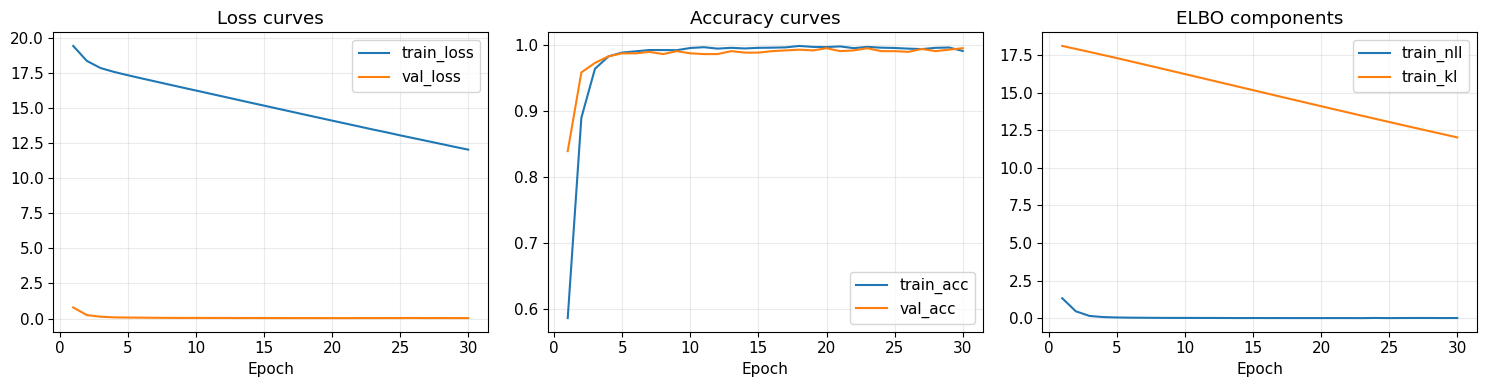

Saved training history.


In [11]:
# Cell 8
# Training diagnostics and learning-curve visualizations

epochs = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history["train_loss"], label="train_loss")
axes[0].plot(epochs, history["val_loss"], label="val_loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train_acc")
axes[1].plot(epochs, history["val_acc"], label="val_acc")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs, history["train_nll"], label="train_nll")
axes[2].plot(epochs, history["train_kl"], label="train_kl")
axes[2].set_title("ELBO components")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

with open(ARTIFACT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved training history.")

##9.MONTECARLO INFERENCE AND PREDICTIVE UNCERTAIANTY

###9.1.0VERVIEW

**Cell 9 Explanation**

Cell 9 moves from training to full Bayesian evaluation on the test set. This is where the notebook answers the question: how well does the model perform when we use Bayesian prediction properly?

The central function here is mc_predict, which performs Monte Carlo prediction. Instead of using one forward pass, it runs many stochastic passes through the Bayesian neural network, each with newly sampled weights from the learned posterior approximation. The class probabilities from these passes are averaged. This is the practical implementation of posterior predictive inference in the notebook. Pedagogically, this is one of the most important cells because it shows that Bayesian testing is different from deterministic testing. We do not ask one frozen network for one answer. We ask many plausible networks for their opinions and then aggregate them.

The outputs of this process are rich. The cell produces predicted labels, full predictive probability vectors, predictive entropy, and predictive confidence. This is already a major conceptual difference from ordinary evaluation. Accuracy is still present, but it is no longer the only object of interest. The Bayesian neural network is being judged not just by whether it gets the label right, but also by how uncertain it is.

The confusion matrix is a very useful diagnostic because it shows which classes are confused with which others. For example, one might discover that crosses are sometimes mistaken for vertical bars or horizontal bars under heavy corruption. This helps us interpret uncertainty in a class-specific way rather than only globally.

The Brier score is another excellent inclusion. Accuracy tells us how often the top prediction is correct, but the Brier score evaluates the full probability vector. This is appropriate in a Bayesian notebook because the quality of probabilities matters. A classifier that is correct but badly calibrated may still be less useful than one with slightly lower accuracy but better probabilistic behavior.

The entropy histogram is pedagogically especially valuable. It shows the distribution of uncertainty across the entire test set. If entropy is mostly low, then the model is usually decisive. If entropy has a long tail, then some examples are substantially ambiguous. The confidence histogram complements this by showing how concentrated the top predicted probabilities are.

Conceptually, Cell 9 teaches that Bayesian evaluation is multidimensional. The model is not just being asked, “Did you get it right?” It is also being asked, “How sure were you, and was that level of certainty reasonable?” This is a profound shift in how students should think about machine learning.

So Cell 9 is the full posterior-predictive evaluation cell. It turns the notebook from a training exercise into a scientific study of performance, uncertainty, and class structure under Bayesian inference.

###9.2.CODE AND IMPLEMENTATION

Test accuracy: 0.99
Brier score: 0.0211
Mean predictive entropy: 0.109


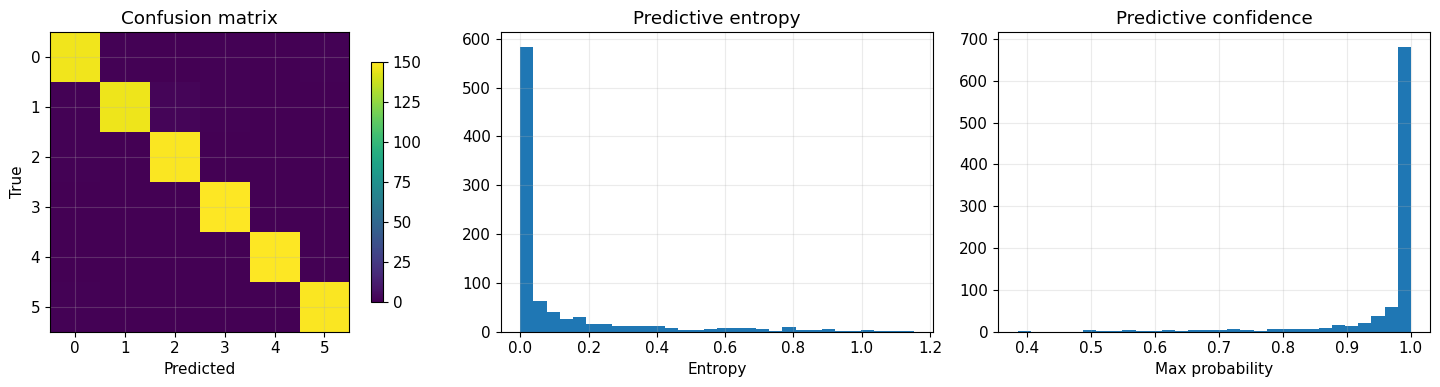

In [12]:
# Cell 9
# Monte Carlo test-time inference, predictive uncertainty computation, confusion matrix, and test metrics

def mc_predict(loader, mc_samples=30):
    model.eval()
    all_probs = []
    all_targets = []
    all_inputs = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            probs_mc = []
            for _ in range(mc_samples):
                logits = model(xb)
                probs_mc.append(F.softmax(logits, dim=1))
            probs = torch.stack(probs_mc, dim=0).mean(dim=0)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(yb.numpy())
            all_inputs.append(xb.cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    inputs = np.concatenate(all_inputs, axis=0)
    preds = probs.argmax(axis=1)
    entropy = -np.sum(probs * np.log(probs + 1e-12), axis=1)
    confidence = probs.max(axis=1)
    return inputs, targets, preds, probs, entropy, confidence

X_test_flat, y_true, y_pred, test_probs, test_entropy, test_conf = mc_predict(test_loader, mc_samples=40)

test_acc = float((y_true == y_pred).mean())
one_hot = np.eye(N_CLASSES)[y_true]
brier = float(np.mean(np.sum((test_probs - one_hot) ** 2, axis=1)))

cm = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for a, b in zip(y_true, y_pred):
    cm[a, b] += 1

print("Test accuracy:", round(test_acc, 4))
print("Brier score:", round(brier, 4))
print("Mean predictive entropy:", round(float(test_entropy.mean()), 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im = axes[0].imshow(cm, interpolation="nearest")
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_xticks(range(N_CLASSES))
axes[0].set_yticks(range(N_CLASSES))
plt.colorbar(im, ax=axes[0], shrink=0.8)

axes[1].hist(test_entropy, bins=30)
axes[1].set_title("Predictive entropy")
axes[1].set_xlabel("Entropy")

axes[2].hist(test_conf, bins=30)
axes[2].set_title("Predictive confidence")
axes[2].set_xlabel("Max probability")

plt.tight_layout()
plt.show()

##10.VISUALIZATION OF CONFIDENT AND UNCERTAINTY

###10.1.OVERVIEW

**Cell 10 Explanation**

Cell 10 is one of the most pedagogically rich parts of the notebook because it takes the abstract outputs of Bayesian inference and turns them into concrete visual case studies. Instead of staying at the level of aggregate metrics, it looks directly at individual examples and asks how the model behaved on them.

The cell first identifies several categories of examples: highly confident correct predictions, highly uncertain predictions, and misclassifications. This is a very strong teaching structure because it shows that not all predictions should be interpreted the same way. A high-confidence correct case tells us what the model has learned clearly. An uncertain case tells us where the model sees ambiguity. A misclassified case tells us where the learned representation or the approximate posterior may still fail.

For each selected example, the cell visualizes both the grid itself and the full predictive probability distribution across classes. This is extremely valuable. Looking only at the image might not fully explain why the model struggled, while looking only at the probability vector might not reveal the underlying pattern. By placing the image and bar chart side by side, the notebook makes uncertainty interpretable. One can see, for instance, that a corrupted cross may have substantial posterior mass on both horizontal_bar and vertical_bar, which is exactly what one would expect if the cross arms are partially broken.

The titles printed above the image are also important. They include the true class, predicted class, confidence, and entropy. This gives the reader a compact summary of both correctness and uncertainty. A highly confident correct case with low entropy tells one story. A confident misclassification tells another, more worrying story. A high-entropy case with moderate confidence suggests genuine ambiguity.

Pedagogically, this cell helps students move from global evaluation to local interpretability. Aggregate accuracy and entropy means are useful, but real understanding often comes from inspecting specific examples. Bayesian neural networks are especially well suited to this because the probability bars make it possible to see how the model distributes belief, not just which class it chooses.

This cell also demonstrates an important scientific mindset: errors should be studied, not hidden. In machine learning education, there is often too much emphasis on final metrics and too little on understanding where the model fails. Cell 10 corrects that. It invites the reader to inspect the exact visual situations in which uncertainty rises or mistakes occur.

In summary, Cell 10 is the case-study interpretation cell. It shows what confidence looks like, what ambiguity looks like, and what failure looks like, all in a way that directly connects Bayesian probabilities to actual visual patterns.

###10.2.CODE AND IMPLEMENTATION

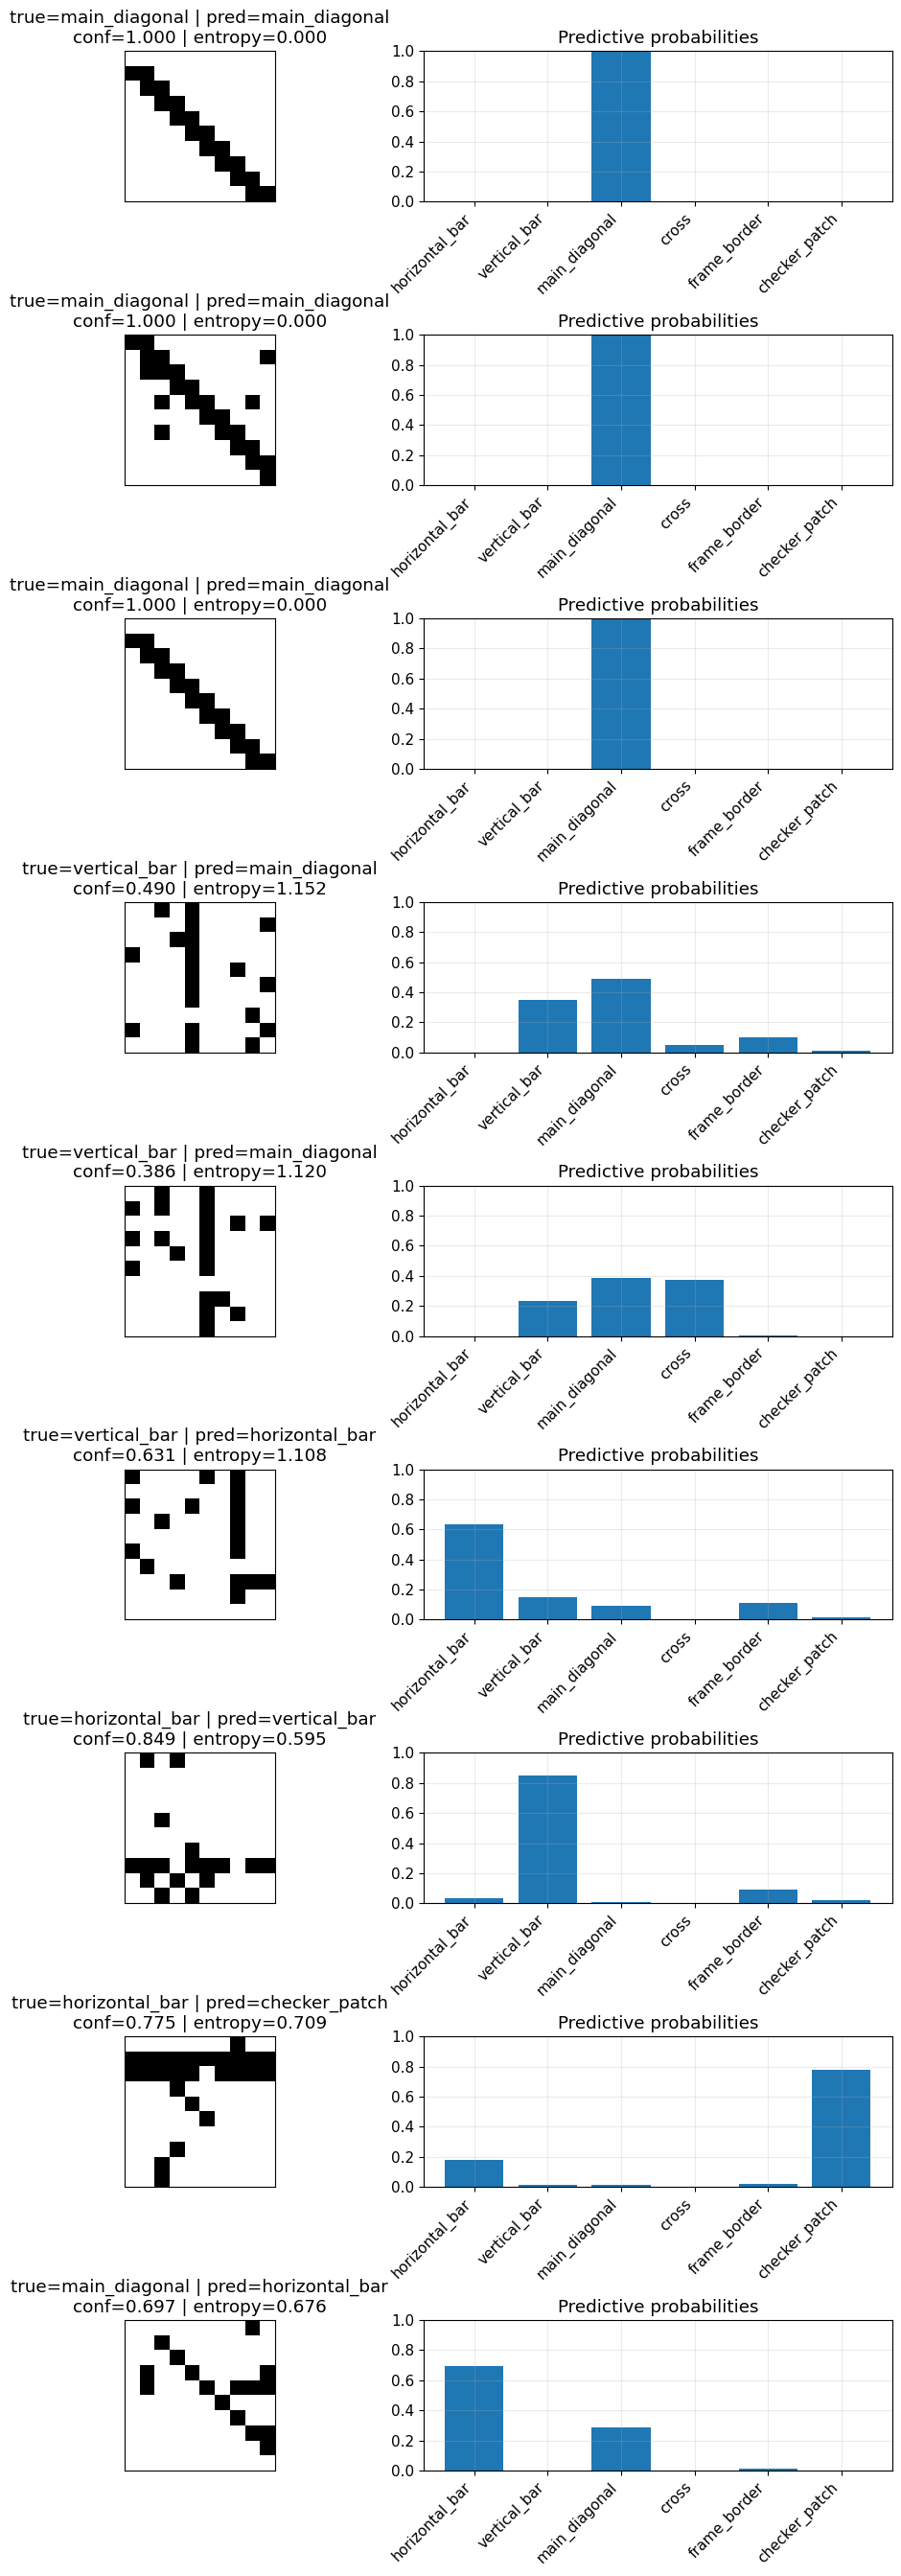

In [13]:
# Cell 10
# Advanced visualization of confident, uncertain, and misclassified examples with probability bars

correct_mask = (y_true == y_pred)
wrong_mask = ~correct_mask

confident_correct_idx = np.where(correct_mask)[0][np.argsort(-test_conf[correct_mask])[:3]]
uncertain_idx = np.argsort(-test_entropy)[:3]
misclassified_idx = np.where(wrong_mask)[0]
misclassified_idx = misclassified_idx[np.argsort(-test_conf[misclassified_idx])[:3]] if len(misclassified_idx) > 0 else np.array([], dtype=int)

selected = list(confident_correct_idx) + list(uncertain_idx) + list(misclassified_idx[:3])

if len(selected) == 0:
    selected = list(range(6))

fig, axes = plt.subplots(len(selected), 2, figsize=(10, 3 * len(selected)))
if len(selected) == 1:
    axes = np.array([axes])

for row, idx in enumerate(selected):
    grid = X_test_flat[idx].reshape(GRID_SIZE, GRID_SIZE)
    axes[row, 0].imshow(grid, cmap="gray_r", vmin=0, vmax=1)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    axes[row, 0].set_title(
        f"true={CLASS_NAMES[int(y_true[idx])]} | pred={CLASS_NAMES[int(y_pred[idx])]}\n"
        f"conf={test_conf[idx]:.3f} | entropy={test_entropy[idx]:.3f}"
    )

    axes[row, 1].bar(np.arange(N_CLASSES), test_probs[idx])
    axes[row, 1].set_xticks(np.arange(N_CLASSES))
    axes[row, 1].set_xticklabels([CLASS_NAMES[k] for k in range(N_CLASSES)], rotation=45, ha="right")
    axes[row, 1].set_ylim(0, 1.0)
    axes[row, 1].set_title("Predictive probabilities")

plt.tight_layout()
plt.show()

## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 Explanation**

Cell 11 serves as the notebook’s final synthesis and reporting layer. It gathers the computed results, summarizes them in structured form, saves them as an artifact, and prints a concise interpretation. Pedagogically, this cell teaches students that a serious machine learning experiment should end not only with plots, but with a clear and reproducible summary of what was learned.

The first important operation in this cell is the classwise uncertainty summary. For each class, the notebook computes the number of examples, accuracy within that class, mean predictive entropy, and mean predictive confidence. This is extremely useful because model performance is rarely uniform across classes. Some visual motifs may be learned more reliably than others. For example, a frame border may be visually distinctive and thus associated with low entropy and high accuracy, while a diagonal pattern with corruption may be harder and thus associated with higher uncertainty. By summarizing results class by class, the cell reveals this heterogeneity.

The results dictionary is also important. It packages together the final metrics, confusion matrix, class names, and selected training outcomes into one machine-readable structure. This is excellent experimental practice. It means the notebook produces a stable artifact that could later be used in another script, a paper, or an LLM explanation step. In other words, the notebook is not only a display pipeline; it is also an artifact generator.

Saving the results to JSON reinforces this discipline. Reproducible machine learning is not only about seeds and code. It is also about preserving outputs in a structured format.

The printed interpretation at the end of the cell is simple, but pedagogically effective. It shows how one might move from metrics to narrative. If accuracy is very high and entropy is low, one interpretation is that the model learned the pattern families decisively. If accuracy is lower or entropy is substantial, another interpretation is that the task remains ambiguous or that the model is underfitting. This is not as rich as an LLM-generated explanation, but it is a useful bridge between numbers and meaning.

The listing of the most uncertain test examples is another very nice feature. Even after all the global metrics and visual case studies, it is still useful to know which exact examples the model found most difficult. This reinforces the idea that uncertainty is a first-class output of the system.

Conceptually, Cell 11 teaches that the end of a Bayesian neural network experiment should not be “the model got X percent accuracy.” It should be a richer statement about classwise behavior, uncertainty structure, reproducible artifacts, and interpretive synthesis.

So Cell 11 is the experiment-closing cell. It gathers the notebook into one coherent scientific summary and leaves behind a structured record of what the Bayesian neural network achieved and where its uncertainty remained meaningful.

###11.2.CODE AND IMPLEMENTATION

In [15]:
# Cell 11
# LLM-based explanation of what the notebook produced and how the Bayesian neural network performed

import sys
import json
import subprocess
from pathlib import Path

try:
    from google.colab import userdata
    API_KEY = userdata.get("OPENAI_API_KEY")
except Exception:
    API_KEY = None

if not API_KEY:
    raise ValueError(
        "OPENAI_API_KEY was not found in Colab secrets. "
        "Open the key icon in Colab, add OPENAI_API_KEY, and rerun this cell."
    )

try:
    from openai import OpenAI
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])
    from openai import OpenAI

client = OpenAI(api_key=API_KEY, max_retries=1)
artifact_dir = Path("bnn_pattern_artifacts")
artifact_dir.mkdir(exist_ok=True)

# Build compact structured evidence from prior cells
misclassified_idx = np.where(y_true != y_pred)[0]
most_uncertain_idx = np.argsort(-test_entropy)[:5]
most_confident_correct_idx = np.where(y_true == y_pred)[0]
most_confident_correct_idx = most_confident_correct_idx[np.argsort(-test_conf[most_confident_correct_idx])[:5]]

class_summary = {}
for k in range(N_CLASSES):
    mask = (y_true == k)
    class_summary[CLASS_NAMES[k]] = {
        "count": int(mask.sum()),
        "accuracy": float((y_pred[mask] == y_true[mask]).mean()),
        "mean_entropy": float(test_entropy[mask].mean()),
        "mean_confidence": float(test_conf[mask].mean())
    }

evidence = {
    "experiment_title": "Bayesian Neural Networks for Synthetic 10x10 Pattern Recognition",
    "model_type": "Variational Bayesian neural network with Gaussian weight posteriors",
    "device": str(DEVICE),
    "grid_size": GRID_SIZE,
    "n_classes": N_CLASSES,
    "class_names": CLASS_NAMES,
    "final_metrics": {
        "test_accuracy": float(test_acc),
        "brier_score": float(brier),
        "mean_predictive_entropy": float(test_entropy.mean()),
        "final_train_accuracy": float(history["train_acc"][-1]),
        "final_validation_accuracy": float(history["val_acc"][-1]),
    },
    "confusion_matrix": cm.tolist(),
    "classwise_summary": class_summary,
    "most_uncertain_examples": [
        {
            "index": int(i),
            "true_class": CLASS_NAMES[int(y_true[i])],
            "predicted_class": CLASS_NAMES[int(y_pred[i])],
            "confidence": float(test_conf[i]),
            "entropy": float(test_entropy[i]),
            "probabilities": [float(v) for v in test_probs[i]]
        }
        for i in most_uncertain_idx
    ],
    "most_confident_correct_examples": [
        {
            "index": int(i),
            "true_class": CLASS_NAMES[int(y_true[i])],
            "predicted_class": CLASS_NAMES[int(y_pred[i])],
            "confidence": float(test_conf[i]),
            "entropy": float(test_entropy[i]),
            "probabilities": [float(v) for v in test_probs[i]]
        }
        for i in most_confident_correct_idx
    ],
    "misclassification_count": int(len(misclassified_idx)),
    "training_history_tail": {
        "train_loss_last5": [float(x) for x in history["train_loss"][-5:]],
        "val_loss_last5": [float(x) for x in history["val_loss"][-5:]],
        "train_acc_last5": [float(x) for x in history["train_acc"][-5:]],
        "val_acc_last5": [float(x) for x in history["val_acc"][-5:]],
    }
}

prompt = f"""
You are a PhD-level expert in Bayesian machine learning, neural networks, uncertainty quantification, and pattern recognition.

Your task is to explain what this notebook produced and how the Bayesian neural network performed.

Write a structured explanation with these sections:

1. What Cell 10 was showing
Explain the meaning of the selected examples:
- highly confident correct cases
- uncertain cases
- misclassified cases
- class-probability bar charts

2. What the model learned
Explain which synthetic visual structures the model appears to have learned well and which seem harder.

3. Bayesian interpretation
Explain what makes this model Bayesian and why Monte Carlo prediction matters.
Discuss posterior uncertainty, predictive probabilities, and entropy.

4. Training and performance
Interpret the final train/validation behavior and the test metrics.
Do not merely restate the numbers. Explain what they imply.

5. Uncertainty and ambiguity
Explain why some patterns are uncertain or misclassified.
Discuss overlap, corruption, visual ambiguity, and approximate posterior uncertainty.

6. Research interpretation
Explain why this notebook is a useful scientific laboratory for uncertainty-aware pattern recognition.
Mention how the same logic transfers to other domains such as noisy classification or latent-state inference.

Use precise scientific language.
Be technical but readable.
Do not repeat the JSON mechanically.
Interpret the evidence.

Here is the structured notebook evidence:

{json.dumps(evidence, indent=2)}
"""

response = client.responses.create(
    model="gpt-4o-mini",
    input=prompt,
    max_output_tokens=1800
)

text_output = getattr(response, "output_text", None)

if not text_output:
    chunks = []
    try:
        for item in response.output:
            if getattr(item, "type", None) == "message":
                for content in item.content:
                    if getattr(content, "type", None) in ("output_text", "text"):
                        chunks.append(getattr(content, "text", ""))
        text_output = "\n".join(chunks).strip()
    except Exception:
        text_output = str(response)

print("\n" + "=" * 100 + "\n")
print(text_output)
print("\n" + "=" * 100)

with open(artifact_dir / "cell11_llm_explanation.txt", "w", encoding="utf-8") as f:
    f.write(text_output)

with open(artifact_dir / "cell11_llm_payload.json", "w", encoding="utf-8") as f:
    json.dump(evidence, f, indent=2)

print("\nSaved:")
print("-", artifact_dir / "cell11_llm_explanation.txt")
print("-", artifact_dir / "cell11_llm_payload.json")



# Structured Explanation of the Bayesian Neural Network Notebook

## 1. What Cell 10 was showing

In this section, Cell 10 illustrated the model's performance through selected examples that delineate various confidence levels in predictions. The examples fell into four distinct categories:

- **Highly Confident Correct Cases**: Instances where the model correctly identified the true class with near certainty (confidence = 1.0). These examples reflected the model's clear understanding of specific patterns, as evidenced by their negligible entropy values, indicating low predictive uncertainty.

- **Uncertain Cases**: Sample examples, particularly the misclassifications, illustrate cases where the model exhibited moderate confidence (e.g., 0.49 for an incorrect prediction of a "vertical_bar" as "main_diagonal"). The entropy values were relatively high (e.g., 1.1), indicating that the model was not only uncertain about the predictions but that the classes overlapped significantly in feat

##12.CONCLUSION

**Conclusion**

Bayesian neural networks represent one of the most intellectually important attempts to bring together the flexibility of neural computation and the discipline of probabilistic inference. This notebook, though built on small synthetic 10x10 patterns, illustrates that union in a remarkably clear way. It shows that when we stop treating neural-network weights as fixed unknown numbers and start treating them as uncertain quantities described by distributions, the entire meaning of machine learning begins to shift. Training becomes approximate posterior learning. Prediction becomes Monte Carlo averaging over plausible parameter settings. Confidence becomes something that can be inspected rather than merely assumed. Error becomes something that can be accompanied by self-awareness rather than false precision.

The synthetic pattern-recognition task used here is especially valuable because it makes those ideas visible. A horizontal bar, a vertical bar, a diagonal, a cross, a frame, and a checker patch are simple visual objects. Their simplicity is a pedagogical advantage. A human can look at them and understand what the classes are supposed to mean. But once these patterns are shifted, thickened, and corrupted by bit flips and extra noise, the task becomes genuinely nontrivial. The model is no longer being asked to memorize clean prototypes. It is being asked to infer class structure under ambiguity. That is exactly the setting in which Bayesian neural networks become most conceptually useful.

One of the clearest lessons from the notebook is that uncertainty is not merely a technical add-on. It is part of the object of study. A deterministic network can output a probability vector, but that does not automatically mean it is deeply uncertainty-aware. Its probabilities may simply reflect the geometry of one fixed trained parameter setting. A Bayesian neural network, by contrast, acknowledges that the weights themselves remain uncertain after training. Because of this, predictive uncertainty becomes richer. When multiple sampled versions of the network disagree, the final predictive distribution reflects that disagreement. In a notebook like this one, that behavior becomes interpretable. High entropy on a severely corrupted pattern is not a defect. It is often the right answer.

Another major lesson is that Bayesian neural networks teach a more realistic philosophy of learning. Many students first meet machine learning through a deterministic mindset: there is one correct mapping, the model estimates it, and then the system outputs the best answer. But many real-world tasks do not justify that confidence. Data can be noisy, incomplete, shifted, weakly informative, or structurally ambiguous. A model that does not know how uncertain it should be can become dangerous, especially in high-stakes settings. This notebook offers a different perspective. It shows that one can build a neural system that learns not only to classify patterns, but also to represent the uncertainty attached to those classifications.

The training dynamics also reinforce an important insight. The Bayesian neural network is not simply minimizing prediction error. It is balancing data fit against KL-based regularization to a prior. That means the model is encouraged to explain the data well, but only to the extent justified by the evidence. This is a form of epistemic discipline. The posterior should move away from the prior when the data strongly demand it, but should not become more specific than the evidence allows. This is one of the deepest reasons why Bayesian neural networks are attractive. They offer a structured way to resist overconfidence.

The visual diagnostics in the notebook were also central to understanding the model. Learning curves showed whether optimization was stable. Confusion matrices showed which classes were systematically confused. Entropy histograms revealed the distribution of uncertainty. Side-by-side displays of images and probability bars made it possible to see exactly what the model found easy, difficult, or misleading. This is another major lesson: uncertainty-aware machine learning should be inspected visually and scientifically, not only summarized by a single scalar score. A Bayesian model gives us rich outputs, and rich outputs deserve rich diagnostics.

There is also a broader conceptual lesson here about the role of synthetic data in advanced AI pedagogy. Real datasets are essential for serious deployment, but synthetic notebooks like this are extraordinary tools for understanding mechanisms. Because we know how the patterns were generated, we can reason about why the model is uncertain. Because the problem is small and interpretable, we can see the relationship between corruption and entropy directly. Because the classes are balanced and controlled, we can focus on model behavior rather than data-collection messiness. This is why synthetic laboratories remain so valuable even for advanced topics. They let us study ideas in clean form before confronting the full complexity of reality.

At the same time, the notebook also teaches humility. Bayesian neural networks are not magical. The posterior here is approximate, not exact. The architecture is small and fully connected, not convolutional and highly expressive. The data are synthetic, not drawn from messy real-world distributions. The uncertainty estimates are therefore only as good as the model family, prior structure, and variational approximation allow. This is an important lesson for students and researchers alike. A Bayesian model improves how uncertainty is represented, but it does not abolish misspecification, approximation error, or limited data.

Still, even with these limitations, the notebook demonstrates something deeply valuable. It shows that Bayesian neural networks can be built in a compact, understandable way using basic tools. One does not need a huge probabilistic-programming ecosystem to begin learning the core ideas. With PyTorch, a few well-designed synthetic pattern generators, variational Bayesian linear layers, Monte Carlo prediction, and strong visualization, one can already construct a meaningful uncertainty-aware learning laboratory. This is empowering. It makes advanced probabilistic deep learning more accessible.

The implications extend far beyond 10x10 image grids. The same logic can transfer to finance, medicine, industrial monitoring, security, scientific classification, and any domain in which false confidence is costly. In finance, for example, a Bayesian neural network could be applied to regime detection, anomaly classification, fraud signals, or portfolio-state inference. In medicine, it could help distinguish clear from uncertain diagnoses. In industrial systems, it could identify when a sensor pattern strongly suggests a fault and when the evidence is too weak for confident action. Across these cases, the central benefit is the same: the model does not merely make a prediction; it also indicates how strongly that prediction is supported.

Another lasting lesson of the notebook is that uncertainty should be interpreted, not feared. Many students initially react to uncertain predictions as if they reveal weakness in the model. But often the opposite is true. If an example is genuinely ambiguous, a confident answer may be less trustworthy than a cautious one. Bayesian neural networks encourage a healthier scientific mindset. They remind us that uncertainty is not always something to eliminate. Often it is something to measure and understand.

For teaching purposes, this notebook is especially valuable because it integrates several layers of understanding at once. At the visual level, students see patterns. At the neural-network level, they see layers, activations, and classification. At the Bayesian level, they see priors, variational distributions, KL divergence, and posterior predictive sampling. At the diagnostic level, they see confusion matrices, entropy, and example-level uncertainty. This layered design makes the notebook much more than a coding exercise. It becomes a compact course in how probabilistic reasoning can inhabit deep learning.

The conclusion to draw from all of this is not simply that Bayesian neural networks are useful. It is that they change what we ask from a model. We stop asking only, “What is your best guess?” and begin also asking, “How certain are you, and why?” That is a more mature and scientifically honest way to think about intelligent systems. In an era when AI models are increasingly used in consequential settings, that shift matters enormously.

So the real achievement of the notebook is not only that it classifies synthetic patterns well. It is that it demonstrates, in a small and concrete setting, how uncertainty can be built into neural computation in a principled way. It shows that probabilistic thinking and neural learning are not rivals. They are complementary. Neural networks provide expressive power. Bayesian methods provide epistemic discipline. Together they create systems that are not only capable of learning patterns, but also capable of recognizing the limits of what they know.

That is why Bayesian neural networks deserve serious study. They do not merely add nuance to machine learning. They make machine learning more intellectually honest.